### 이진화

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

##### 단순 이진화

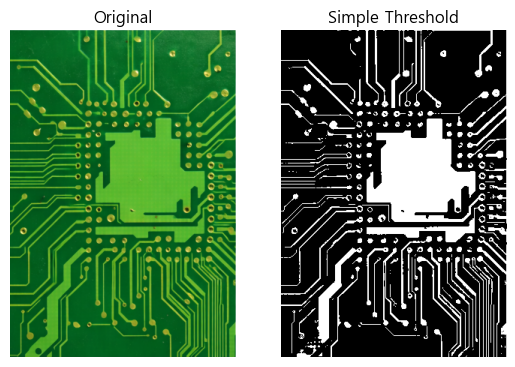

In [9]:
# 원본 이미지 읽기
original_image = cv2.imread('../images/pcb_normal.png')

# 이진화: Simple Threshold
thresh, binary_image = cv2.threshold(
    src=cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY), 
    thresh=127, 
    maxval=255, 
    type=cv2.THRESH_BINARY
)

# 비교 시각화
fig, axes = plt.subplots(1, 2)

axes[0].set_title("Original", fontsize=12)
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].set_title("Simple Threshold", fontsize=12)
axes[1].imshow(binary_image, cmap='gray')
axes[1].axis("off")

plt.show()


##### 오츠 이진화

Otsu's threshold value: 101.0


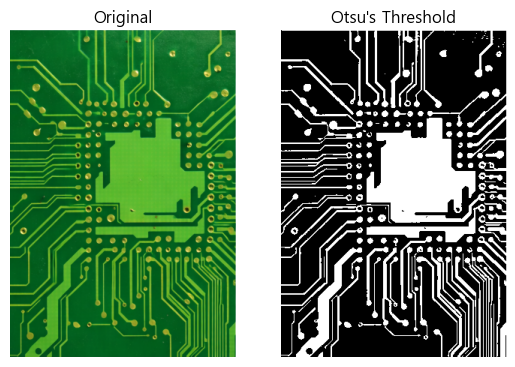

In [10]:
# 원본 이미지 읽기
original_image = cv2.imread('../images/pcb_normal.png')

# 이진화: Otsu's Threshold
thresh, binary_image = cv2.threshold(
    src=cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY), 
    thresh=0, 
    maxval=255, 
    type=cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f"Otsu's threshold value: {thresh}")

# 비교 시각화
fig, axes = plt.subplots(1, 2)

axes[0].set_title("Original", fontsize=12)
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].set_title("Otsu's Threshold", fontsize=12)
axes[1].imshow(binary_image, cmap='gray')
axes[1].axis("off")

plt.show()

##### 적응형 이진화

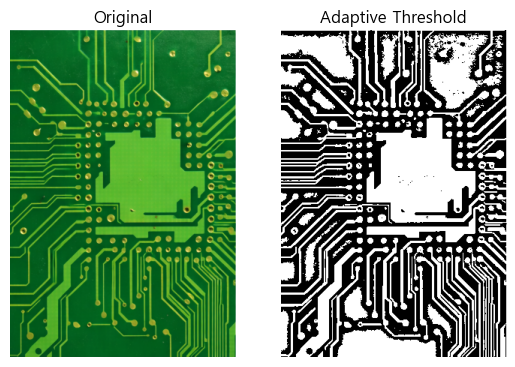

In [21]:
# 원본 이미지 읽기
original_image = cv2.imread('../images/pcb_normal.png')

# 이진화: Adaptive Threshold
binary_image = cv2.adaptiveThreshold(
    src=cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY), 
    # 흰색으로 설정할 값
    maxValue=255,
    # 주변 픽셀의 밝기 평균을 구하기 위해 가우시안 가중 평균 사용
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    # 임계값 이하:0, 이상:255로 변환
    thresholdType=cv2.THRESH_BINARY, 
    # 주변 픽셀 블록 크기 (중앙 픽셀이 있는 홀수로 지정, 기본값: 31x31)
    blockSize=31,
    # 계산된 임계값에서 빼는 보정 상수(기본값: 5)
    # 너무 밝게 판단되는 것을 조금 완화
    C=5
)   

# 비교 시각화
fig, axes = plt.subplots(1, 2)

axes[0].set_title("Original", fontsize=12)
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].set_title("Adaptive Threshold", fontsize=12)
axes[1].imshow(binary_image, cmap='gray')
axes[1].axis("off")

plt.show()